# **TEMA: MERCADOS DE APOSTAS DE FUTEBOL DA CHAMPIONS LEAGUE - POLYMARKET**

# **Introdução**

**PERGUNTA:**

Como se distribui o volume negociado nos mercados relacionados à Champions League e quais mercados apresentam comportamento atípico?

**HIPÓTESE**

Mercados envolvendo favoritos ou momentos decisivos concentram volumes significativamente superiores à média.

# **Exploração Inicial**

**Query Principal:**

SELECT
    event_title,
    question,
    volume,
    created_at,
    end_date,
    closed
FROM `even-continuity-441888-j0.polymarket_optimized.markets`
WHERE LOWER(event_title) LIKE '%champions league%'
ORDER BY volume DESC
LIMIT 1000

Esta consulta inicial foi utilizada para localizar os mercados relacionados à UEFA Champions League dentro da base do Polymarket.

**Objetivo:** delimitar o universo de dados antes de calcular estatísticas ou criar alertas.

**Observação:** o recorte reúne os mercados associados à competição e as colunas necessárias para analisar volume, criação e encerramento.

**Interpretação:** começar pelo recorte correto evita misturar mercados de outras competições e cria uma base consistente para as análises seguintes.

**Limitação:** a seleção por texto depende da forma como a competição está registrada na base. Mercados relacionados à Champions League que não contenham o termo esperado podem não aparecer.

**Segunda Query:**

SELECT
AVG(volume) AS media_volume
FROM `even-continuity-441888-j0.polymarket_optimized.markets`
WHERE LOWER(event_title) LIKE '%champions league%'
LIMIT 1000

Esta consulta foi utilizada para calcular a média de volume dos mercados selecionados.

**Objetivo:** criar uma referência de volume para comparar mercados individuais com o comportamento geral.

**Observação:** a média fornece uma medida central da distribuição dos volumes.

**Interpretação:** mercados muito acima da média merecem investigação porque podem representar concentração de atividade.

**Limitação:** valores extremos podem elevar a média. Por isso, os alertas finais também utilizam o desvio-padrão.

In [ ]:
import pandas as pd

In [11]:
df = pd.read_csv('volume_medio.csv')

In [12]:
df.head()

,media_volume
0,1.359871e+06


**Terceira Query:**

SELECT COUNT(*) AS total_mercados
FROM `even-continuity-441888-j0.polymarket_optimized.markets`
WHERE LOWER(event_title) LIKE '%champions league%'
LIMIT 1000

Esta consulta reuniu os mercados selecionados para a análise exploratória.

**Objetivo:** obter a unidade de análise utilizada nas etapas de estatística descritiva, visualização e construção dos alertas.

A partir desse conjunto foram avaliados volume, datas de criação e encerramento e situação dos mercados.

**Limitação:** a análise utiliza as informações disponíveis na tabela de mercados e não acompanha diretamente cada negociação individual.

# **Análise Exploratória**

In [13]:
df = pd.read_csv('total_mercados.csv')

In [14]:
df.head()

,total_mercados
0,936


Leitura do csv da query principal


In [ ]:
df = pd.read_csv('query_champions_league.csv')

**5 primeiras linhas**

In [4]:
df.head()

,event_title,question,volume,created_at,end_date,closed
0,Champions League Winner,Will Aston Villa win the UEFA Champions League?,1.331138e+08,2024-09-17 17:21:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
1,Champions League Winner,Will Inter Milan win the UEFA Champions League?,8.297866e+07,2024-09-17 17:27:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
2,Champions League Winner,Will Red Star Belgrade win the UEFA Champions ...,6.928181e+07,2024-09-17 17:35:44.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
3,Champions League Winner,Will Paris Saint-Germain win the UEFA Champion...,5.132058e+07,2024-09-17 17:30:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
4,Champions League Winner,Will Bayer Leverkusen win the UEFA Champions L...,4.678024e+07,2024-09-17 17:23:02.000000 UTC,2025-05-31 12:00:00.000000 UTC,1


**tipo das colunas**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   event_title  936 non-null    object 
 1   question     936 non-null    object 
 2   volume       936 non-null    float64
 3   created_at   936 non-null    object 
 4   end_date     936 non-null    object 
 5   closed       936 non-null    int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 44.0+ KB


O conjunto analisado possui **936 registros e 6 colunas**.

**Observação:** a estrutura contém as informações necessárias para a análise e não apresentou problemas de tipo nas colunas utilizadas.

**Interpretação:** a estrutura permite seguir com estatísticas descritivas, conversão das datas e análise dos volumes.

**Limitação:** a ausência de problemas estruturais não garante que todos os registros representem igualmente o comportamento dos participantes.

**resumo estatístico**

In [6]:
df.describe()

,volume,closed
count,9.360000e+02,936.000000
mean,1.359871e+06,0.873932
std,7.470906e+06,0.332104
min,0.000000e+00,0.000000
25%,1.252456e+02,1.000000
50%,6.430000e+02,1.000000
75%,1.472908e+04,1.000000
max,1.331138e+08,1.000000


**valores nulos**

In [7]:
df.isnull().sum()

,0
event_title,0
question,0
volume,0
created_at,0
end_date,0
closed,0


A verificação de valores nulos não encontrou valores ausentes nas colunas analisadas.

**Observação:** volume e datas puderam ser utilizados sem imputação de valores.

**Importância para os alertas:** valores ausentes poderiam alterar a média, o desvio-padrão e os mercados classificados.

**Limitação:** ausência de nulos não garante que todos os valores preenchidos sejam semanticamente corretos.

**converter datas**

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['end_date'] = pd.to_datetime(df['end_date'])

**valores duplicados**

In [9]:
df.duplicated().sum()

np.int64(0)

### Mercados com maior volume

A ordenação dos mercados pelo volume permite identificar diretamente os eventos que concentram maior atividade financeira.

**Observação:** poucos mercados apresentam volumes muito superiores aos demais.

**Hipótese:** essa concentração pode estar relacionada ao maior interesse dos participantes em determinados eventos, equipes ou momentos da competição.

**Limitação:** volume elevado indica atividade financeira, mas não explica sozinho por que o mercado recebeu mais negociações.

In [17]:
df.sort_values("volume", ascending=False).head(10)

,event_title,question,volume,created_at,end_date,closed
0,Champions League Winner,Will Aston Villa win the UEFA Champions League?,1.331138e+08,2024-09-17 17:21:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
1,Champions League Winner,Will Inter Milan win the UEFA Champions League?,8.297866e+07,2024-09-17 17:27:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
2,Champions League Winner,Will Red Star Belgrade win the UEFA Champions ...,6.928181e+07,2024-09-17 17:35:44.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
3,Champions League Winner,Will Paris Saint-Germain win the UEFA Champion...,5.132058e+07,2024-09-17 17:30:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
4,Champions League Winner,Will Bayer Leverkusen win the UEFA Champions L...,4.678024e+07,2024-09-17 17:23:02.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
5,Champions League Winner,Will Stade Brestois win the UEFA Champions Lea...,4.117969e+07,2024-09-17 17:38:07.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
6,Champions League Winner,Will Bologna win the UEFA Champions League?,3.695271e+07,2024-09-17 17:25:01.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
7,Champions League Winner,Will Benfica win the UEFA Champions League?,3.539784e+07,2024-09-17 17:24:01.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
8,Champions League Winner,Will Slovan Bratislava win the UEFA Champions ...,3.213092e+07,2024-09-17 17:36:37.000000 UTC,2025-05-31 12:00:00.000000 UTC,1
9,Champions League Winner,Will Monaco win the UEFA Champions League?,3.107659e+07,2024-09-17 17:29:50.000000 UTC,2025-05-31 12:00:00.000000 UTC,1


### Volume médio

A média de volume é utilizada como referência para avaliar o comportamento geral dos mercados.

Ela permite comparar cada mercado com um valor central da distribuição. Como valores extremos podem aumentar a média, ela não é utilizada isoladamente para definir os alertas.

Por isso, os alertas finais também consideram o desvio-padrão.

In [18]:
df['volume'].mean()

np.float64(1359870.5659532808)

### Volume máximo

O volume máximo mostra o maior valor observado no conjunto.

Essa medida ajuda a dimensionar a diferença entre os mercados mais movimentados e o restante da distribuição.

Quando o máximo fica muito distante da média, existe evidência de concentração de volume, o que motivou a criação dos alertas.

In [19]:
df['volume'].max()

133113813.382904

### Volume mínimo

O volume mínimo representa o menor volume observado entre os mercados selecionados.

A comparação entre mínimo, média e máximo ajuda a entender a amplitude da distribuição e reforça a necessidade de observar a dispersão dos volumes.

In [20]:
df['volume'].min()

0.0

### Mercados encerrados

A contagem de mercados encerrados permite observar como os mercados se distribuem em relação ao seu status.

Essa variável também ajuda a interpretar os alertas, pois um alto volume pode aparecer em mercados com diferentes situações.

**Limitação:** o status do mercado não permite inferir sozinho se houve uma mudança relevante próximo ao encerramento.

In [21]:
df['closed'].value_counts()

,count
closed,
1,818
0,118


# **Gráficos**

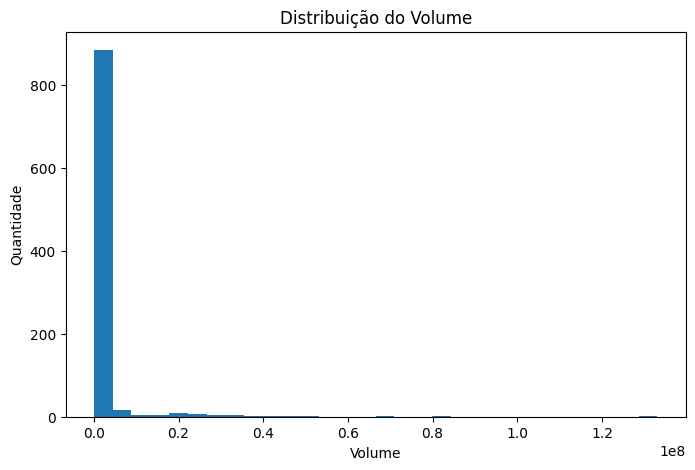

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["volume"], bins=30)
plt.title("Distribuição do Volume")
plt.xlabel("Volume")
plt.ylabel("Quantidade")
plt.show()

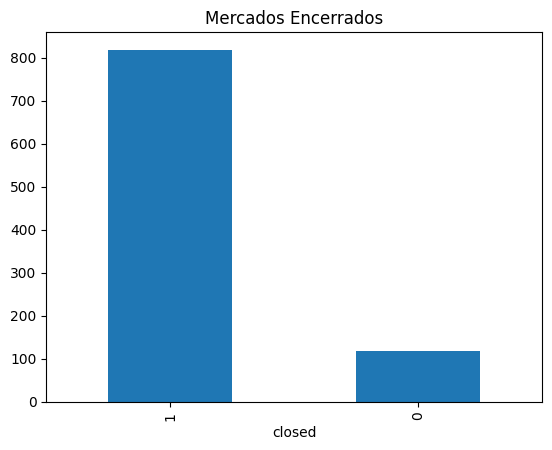

In [24]:
df["closed"].value_counts().plot(kind="bar")

plt.title("Mercados Encerrados")
plt.show()

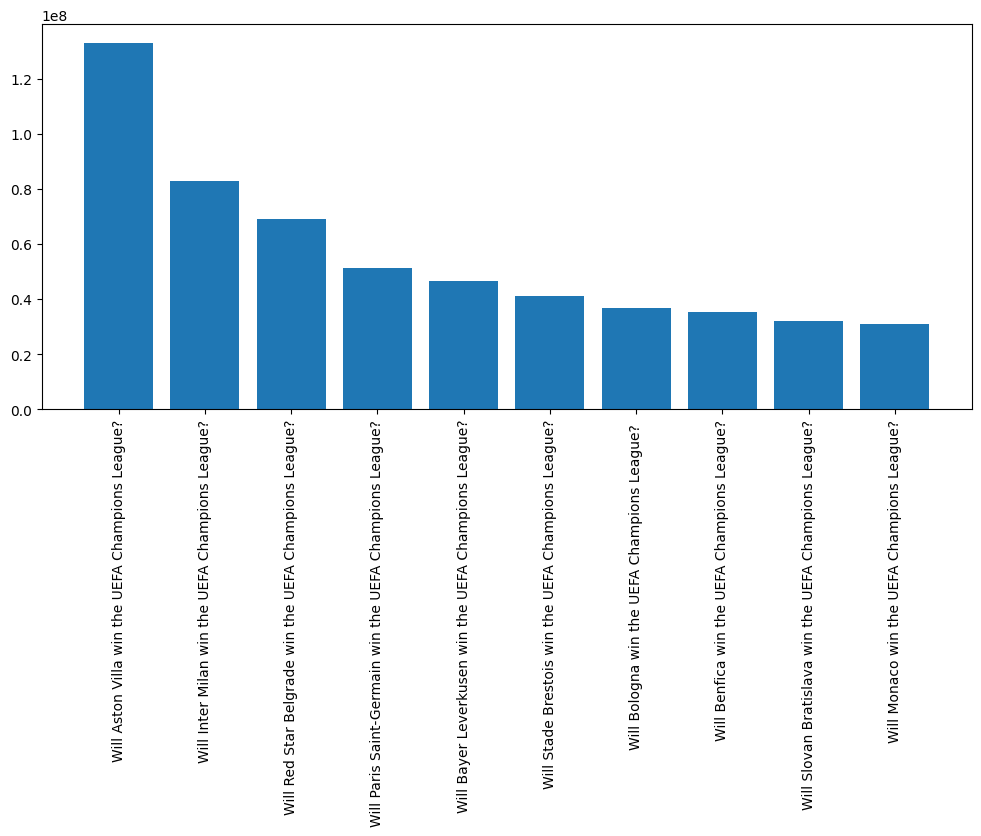

In [25]:
top10 = df.sort_values("volume", ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(top10["question"], top10["volume"])
plt.xticks(rotation=90)
plt.show()

# **Alerta 1**

Mostra apenas os mercados cujo volume seja maior que essa média (ou 2 vezes essa média).

# **Alerta 1 — Alto volume por z-score**

O primeiro alerta transforma a observação de concentração de volume em uma regra estatística.

A regra utilizada é o **z-score do volume**. O z-score mede quantos desvios-padrão um mercado está acima ou abaixo da média.

- `z_score >= 2`: mercado considerado de alto volume;
- `z_score < 2`: mercado não dispara o alerta.

A consulta foi organizada em CTEs para separar seleção, limpeza, cálculo das estatísticas, cálculo do z-score, classificação e filtragem.

O resultado final contém somente os registros que satisfazem a regra.

In [ ]:
-- ALERTA 1: identifica mercados com volume estatisticamente anormal.
-- Regra: z-score do volume superior a 2 desvios-padrao.
-- A consulta retorna somente os mercados que ultrapassam esse limite.

WITH
champions AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed
    FROM
        `even-continuity-441808-j0.polymarket_optimized.markets`
    WHERE
        LOWER(event_title) LIKE '%champions%'
),
dados_validos AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed
    FROM
        champions
    WHERE
        volume IS NOT NULL
        AND volume >= 0
),
estatisticas AS (
    SELECT
        AVG(volume) AS media_volume,
        STDDEV_POP(volume) AS desvio_volume,
        COUNT(*) AS quantidade_mercados
    FROM
        dados_validos
),
base_calculada AS (
    SELECT
        d.market_id,
        d.event_title,
        d.question,
        d.volume,
        d.created_at,
        d.end_date,
        d.closed,
        e.media_volume,
        e.desvio_volume,
        e.quantidade_mercados
    FROM
        dados_validos AS d
    CROSS JOIN
        estatisticas AS e
),
z_scores AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed,
        media_volume,
        desvio_volume,
        quantidade_mercados,
        SAFE_DIVIDE(
            volume - media_volume,
            desvio_volume
        ) AS z_score
    FROM
        base_calculada
),
mercados_classificados AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed,
        media_volume,
        desvio_volume,
        quantidade_mercados,
        z_score,
        CASE
            WHEN z_score >= 2 THEN 'ALTO_VOLUME'
            ELSE 'NORMAL'
        END AS classificacao
    FROM
        z_scores
),
alertas AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        z_score,
        classificacao
    FROM
        mercados_classificados
    WHERE
        classificacao = 'ALTO_VOLUME'
        AND z_score >= 2
)
SELECT
    market_id,
    event_title,
    question,
    volume,
    created_at,
    end_date,
    z_score,
    classificacao
FROM
    alertas
WHERE
    volume IS NOT NULL
ORDER BY
    z_score DESC,
    volume DESC,
    created_at ASC;

### Interpretação do Alerta 1

O arquivo de resultado do alerta contém **63 mercados** classificados com z-score igual ou superior a 2.

Isso indica que esses mercados apresentam volume significativamente acima da média do conjunto segundo o critério escolhido.

O maior z-score observado é **55,15**, mostrando que existem mercados extremamente distantes da média.

**Hipótese:** mercados com volumes muito acima da distribuição podem representar eventos de maior interesse ou maior concentração financeira.

**Limitação:** o alerta identifica anomalia de volume, mas não prova uma causa específica nem representa recomendação de aposta.

In [26]:
df = pd.read_csv('aviso1.csv')

In [27]:
df.head()

,question,volume,media_volume
0,Will Aston Villa win the UEFA Champions League?,1.331138e+08,161413.893588
1,Will Inter Milan win the UEFA Champions League?,8.297866e+07,161413.893588
2,Will Red Star Belgrade win the UEFA Champions ...,6.928181e+07,161413.893588
3,Will Paris Saint-Germain win the UEFA Champion...,5.132058e+07,161413.893588
4,Will Bayer Leverkusen win the UEFA Champions L...,4.678024e+07,161413.893588


# **Alerta 2**

identifica os mercados que ainda estão abertos e já possuem grande movimentação.

# **Alerta 2 — Volume acima da faixa estatística**

O segundo alerta usa uma regra estatística diferente: considera como alerta os mercados cujo volume ultrapassa a **média + 2 desvios-padrão**.

A regra procura mercados com volume excepcionalmente alto dentro da distribuição.

A consulta separa as etapas em CTEs para deixar explícitos o cálculo do limite, a classificação e a filtragem final.

Embora a exploração inicial tenha observado o status dos mercados, o alerta final foi consolidado como um alerta de volume estatisticamente elevado, mantendo conexão direta com o principal padrão encontrado na EDA.

In [ ]:
-- ALERTA 2: identifica mercados com volume acima da faixa estatistica.
-- Regra: volume superior a media + 2 desvios-padrao.
-- O objetivo e encontrar mercados que se destacam na distribuicao de volume.

WITH
champions AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed
    FROM
        `even-continuity-441808-j0.polymarket_optimized.markets`
    WHERE
        LOWER(event_title) LIKE '%champions%'
),
dados_validos AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed
    FROM
        champions
    WHERE
        volume IS NOT NULL
        AND volume >= 0
),
estatisticas AS (
    SELECT
        AVG(volume) AS media_volume,
        STDDEV_POP(volume) AS desvio_volume,
        COUNT(*) AS quantidade_mercados
    FROM
        dados_validos
),
limites AS (
    SELECT
        media_volume,
        desvio_volume,
        quantidade_mercados,
        media_volume + (2 * desvio_volume) AS limite_alerta,
        media_volume + desvio_volume AS limite_atencao
    FROM
        estatisticas
),
base_com_limite AS (
    SELECT
        d.market_id,
        d.event_title,
        d.question,
        d.volume,
        d.created_at,
        d.end_date,
        d.closed,
        l.media_volume,
        l.desvio_volume,
        l.quantidade_mercados,
        l.limite_alerta,
        l.limite_atencao
    FROM
        dados_validos AS d
    CROSS JOIN
        limites AS l
),
classificacao AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed,
        media_volume,
        desvio_volume,
        quantidade_mercados,
        limite_alerta,
        limite_atencao,
        CASE
            WHEN volume > limite_alerta THEN 'ALTO_VOLUME'
            WHEN volume > limite_atencao THEN 'ATENCAO'
            ELSE 'NORMAL'
        END AS tipo_alerta
    FROM
        base_com_limite
),
somente_alertas AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed,
        media_volume,
        desvio_volume,
        limite_alerta,
        tipo_alerta
    FROM
        classificacao
    WHERE
        tipo_alerta = 'ALTO_VOLUME'
        AND volume > limite_alerta
),
resultado_final AS (
    SELECT
        market_id,
        event_title,
        question,
        volume,
        created_at,
        end_date,
        closed,
        media_volume,
        desvio_volume,
        limite_alerta,
        tipo_alerta
    FROM
        somente_alertas
    WHERE
        volume IS NOT NULL
        AND limite_alerta IS NOT NULL
)
SELECT
    market_id,
    event_title,
    question,
    volume,
    created_at,
    end_date,
    closed,
    media_volume,
    desvio_volume,
    limite_alerta,
    tipo_alerta
FROM
    resultado_final
WHERE
    volume > limite_alerta
ORDER BY
    volume DESC,
    created_at ASC;

### Interpretação do Alerta 2

O resultado original contém **292 registros** classificados como `ALTO_VOLUME_ENCERRADO`.

A regra destaca mercados cujo volume ultrapassa a faixa estatística superior definida pela média mais dois desvios-padrão.

**Observação:** os resultados reforçam a existência de uma parcela de mercados com volume muito acima do comportamento central.

**Hipótese:** esses mercados podem representar maior interesse dos participantes ou maior concentração de atividade financeira.

**Limitação:** a regra não identifica causalidade e não deve ser interpretada como recomendação de negociação.

In [28]:
df = pd.read_csv('aviso2.csv')

In [29]:
df.head()

,question,volume
0,Will Aston Villa win the UEFA Champions League?,1.331138e+08
1,Will Inter Milan win the UEFA Champions League?,8.297866e+07
2,Will Red Star Belgrade win the UEFA Champions ...,6.928181e+07
3,Will Paris Saint-Germain win the UEFA Champion...,5.132058e+07
4,Will Bayer Leverkusen win the UEFA Champions L...,4.678024e+07


# **Conclusão**

A análise exploratória dos mercados relacionados à UEFA Champions League mostrou uma distribuição concentrada do volume negociado. A comparação entre os mercados, a média, o máximo e a distribuição dos volumes indicou que poucos mercados apresentam valores muito superiores ao comportamento central.

Esse resultado **corrobora parcialmente a hipótese inicial** de que determinados mercados concentram maior atividade financeira.

O **Alerta 1**, baseado no z-score, identifica mercados que estão pelo menos dois desvios-padrão acima da média. O resultado contém 63 mercados e permite visualizar diretamente o grau de afastamento da média.

O **Alerta 2**, baseado no limite `média + 2 × desvio-padrão`, identifica uma faixa de volume excepcionalmente elevada. O resultado original contém 292 registros.

Os dois alertas transformam uma observação exploratória em regras reproduzíveis de monitoramento. Eles não afirmam que os mercados alertados possuem maior probabilidade de determinado resultado nem constituem recomendação de aposta.

### Limitações

A análise depende do recorte de mercados disponível na base e da forma como os eventos foram registrados. Além disso, volume elevado pode ter diferentes explicações que não podem ser determinadas apenas com essas variáveis.

### Resultado final

A EDA, as consultas SQL, as visualizações e os alertas formam uma sequência analítica: primeiro o universo de mercados é delimitado, depois o volume é explorado, em seguida os padrões são quantificados e, por fim, as regras de alerta são aplicadas aos registros considerados relevantes.

A análise mostrou que os mercados relacionados à Champions League apresentam forte concentração de volume em poucos mercados, corroborando parcialmente a hipótese inicial. Os alertas desenvolvidos conseguiram identificar mercados de maior interesse utilizando critérios estatísticos e de status do mercado.